## jupyter版本

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


In [3]:
# =========================
# 参数
# =========================
EXPR_PATH = "/Users/chengyuhang/Desktop/HCC复发预测项目/GSE76427_expr_gene_RFS_108_clean.csv"
LABEL_PATH = "/Users/chengyuhang/Desktop/HCC复发预测项目/GSE76427_rfs_label_108.csv"

TOPK_GENES = 90
EPOCHS = 260
LR = 5e-4
RANDOM_SEED = 42

FIG_DIR = "/Users/chengyuhang/Desktop/model_figures"
os.makedirs(FIG_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [4]:
# =========================
# 读取数据
# =========================
df = pd.read_csv(EXPR_PATH, index_col=0)

label_df = pd.read_csv(LABEL_PATH)

label_df = label_df.rename(columns={
    "sample": "sample_id",
    "recurrence": "label"
})

label_df["label"] = label_df["label"].astype(int)

common_samples = [s for s in df.columns if s in set(label_df["sample_id"])]

df = df[common_samples]

label_df = (
    label_df
    .set_index("sample_id")
    .loc[common_samples]
    .reset_index()
)

gene_names_all = np.array(df.index.tolist())
sample_names = np.array(df.columns.tolist())

X = df.values.T.astype(np.float32)
y = label_df["label"].values.astype(int)

print("Samples:", X.shape[0])
print("Genes:", X.shape[1])


Samples: 108
Genes: 31333


In [5]:
# =========================
# train / val / test
# =========================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_trainval
)

print("Train:", X_train.shape[0])
print("Val:", X_val.shape[0])
print("Test:", X_test.shape[0])


Train: 64
Val: 22
Test: 22


In [6]:
# =========================
# 差异基因筛选
# =========================
def select_genes_by_tscore(X_train, y_train, gene_names, topk=100):

    pos = X_train[y_train == 1]
    neg = X_train[y_train == 0]

    pos_mean = pos.mean(axis=0)
    neg_mean = neg.mean(axis=0)

    pos_var = pos.var(axis=0)
    neg_var = neg.var(axis=0)

    n_pos = pos.shape[0]
    n_neg = neg.shape[0]

    se = np.sqrt(pos_var / n_pos + neg_var / n_neg)
    se[se == 0] = 1e-6

    t_score = (pos_mean - neg_mean) / se
    abs_t = np.abs(t_score)

    top_idx = np.argsort(abs_t)[::-1][:topk]

    selected_info = pd.DataFrame({
        "gene": gene_names[top_idx],
        "t_score": t_score[top_idx],
        "abs_t_score": abs_t[top_idx]
    })

    return top_idx, selected_info


top_idx, selected_gene_info = select_genes_by_tscore(
    X_train,
    y_train,
    gene_names_all,
    TOPK_GENES
)

selected_genes = gene_names_all[top_idx]

X_train = X_train[:, top_idx]
X_val = X_val[:, top_idx]
X_test = X_test[:, top_idx]

selected_gene_info.head()


,gene,t_score,abs_t_score
0,LOC440864,-4.574350,4.574350
1,LOC648638,-4.487353,4.487353
2,LOC100129058,-4.203839,4.203839
3,FAM108A2,-4.170223,4.170223
4,LOC100133487,4.122568,4.122568


In [8]:
# =========================
# 标准化
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [9]:
# =========================
# MLP
# =========================
class MLPClassifier(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.feature_extractor = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Linear(16, 1)

    def forward(self, x):

        embedding = self.feature_extractor(x)

        logits = self.classifier(embedding).squeeze(1)

        return logits, embedding


model = MLPClassifier(input_dim=TOPK_GENES)
model


MLPClassifier(
  (feature_extractor): Sequential(
    (0): Linear(in_features=90, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (classifier): Linear(in_features=16, out_features=1, bias=True)
)

In [10]:
# =========================
# Tensor
# =========================
x_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

x_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

x_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-3
)


In [11]:
# =========================
# 训练 MLP
# =========================
best_val_loss = float("inf")
best_state = None

train_loss_history = []
val_loss_history = []

for epoch in tqdm(range(EPOCHS)):

    model.train()

    optimizer.zero_grad()

    train_logits, train_embedding = model(x_train_t)

    loss = criterion(train_logits, y_train_t)

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_logits, val_embedding = model(x_val_t)

        val_loss = criterion(val_logits, y_val_t).item()

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_state = model.state_dict()

model.load_state_dict(best_state)

print("MLP training finished.")


  0%|          | 0/260 [00:00<?, ?it/s]

MLP training finished.


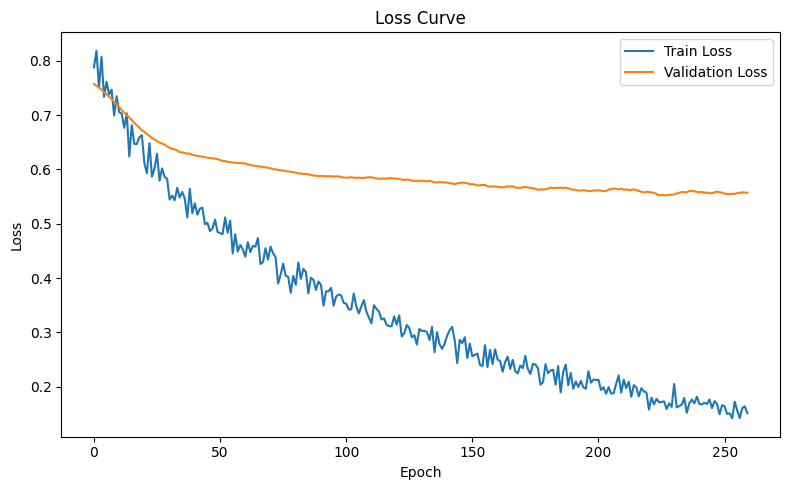

In [12]:
# =========================
# Loss 曲线
# =========================
plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "loss_curve.png"), dpi=300)

plt.show()


In [13]:
# =========================
# Logistic Regression
# =========================
logreg = LogisticRegression(
    penalty="elasticnet",
    l1_ratio=0.5,
    C=0.5,
    class_weight="balanced",
    solver="saga",
    max_iter=3000,
    random_state=RANDOM_SEED
)

logreg.fit(X_train_scaled, y_train)

print("Logistic Regression finished.")


Logistic Regression finished.


In [14]:
# =========================
# 三种模型预测概率
# =========================
model.eval()

with torch.no_grad():

    mlp_val_logits, mlp_val_embedding = model(x_val_t)
    mlp_test_logits, mlp_test_embedding = model(x_test_t)

    mlp_val_prob = torch.sigmoid(mlp_val_logits).numpy()
    mlp_test_prob = torch.sigmoid(mlp_test_logits).numpy()

logreg_val_prob = logreg.predict_proba(X_val_scaled)[:, 1]
logreg_test_prob = logreg.predict_proba(X_test_scaled)[:, 1]

ensemble_val_prob = (
    mlp_val_prob + logreg_val_prob
) / 2

ensemble_test_prob = (
    mlp_test_prob + logreg_test_prob
) / 2


In [15]:
# =========================
# 找最佳阈值
# =========================
def find_best_threshold(y_true, y_prob):

    best_threshold = 0.5
    best_f1 = -1

    for threshold in np.arange(0.01, 1.00, 0.01):

        pred = (y_prob >= threshold).astype(int)

        current_f1 = f1_score(
            y_true,
            pred,
            zero_division=0
        )

        if current_f1 > best_f1:

            best_f1 = current_f1
            best_threshold = threshold

    return best_threshold


mlp_best_threshold = find_best_threshold(
    y_val,
    mlp_val_prob
)

logreg_best_threshold = find_best_threshold(
    y_val,
    logreg_val_prob
)

ensemble_best_threshold = find_best_threshold(
    y_val,
    ensemble_val_prob
)

print("MLP threshold:", mlp_best_threshold)
print("Logistic threshold:", logreg_best_threshold)
print("Ensemble threshold:", ensemble_best_threshold)


MLP threshold: 0.22
Logistic threshold: 0.15
Ensemble threshold: 0.33


In [16]:
# =========================
# 模型评估函数
# =========================
def evaluate_model_by_prob(
    y_true,
    y_prob,
    threshold,
    model_name
):

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision_value = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1_value = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    roc_auc_value = auc(fpr, tpr)

    ap_value = average_precision_score(
        y_true,
        y_prob
    )

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
        "auc": roc_auc_value,
        "average_precision": ap_value
    }


mlp_result = evaluate_model_by_prob(
    y_test,
    mlp_test_prob,
    mlp_best_threshold,
    "MLP"
)

logreg_result = evaluate_model_by_prob(
    y_test,
    logreg_test_prob,
    logreg_best_threshold,
    "Logistic Regression"
)

ensemble_result = evaluate_model_by_prob(
    y_test,
    ensemble_test_prob,
    ensemble_best_threshold,
    "MLP + Logistic"
)

model_compare_df = pd.DataFrame([
    mlp_result,
    logreg_result,
    ensemble_result
])

print(model_compare_df)


                 model  accuracy  precision  recall        f1       auc  \
0                  MLP  0.545455   0.500000     0.8  0.615385  0.666667   
1  Logistic Regression  0.636364   0.571429     0.8  0.666667  0.633333   
2       MLP + Logistic  0.590909   0.545455     0.6  0.571429  0.641667   

   average_precision  
0           0.700058  
1           0.590391  
2           0.677967  


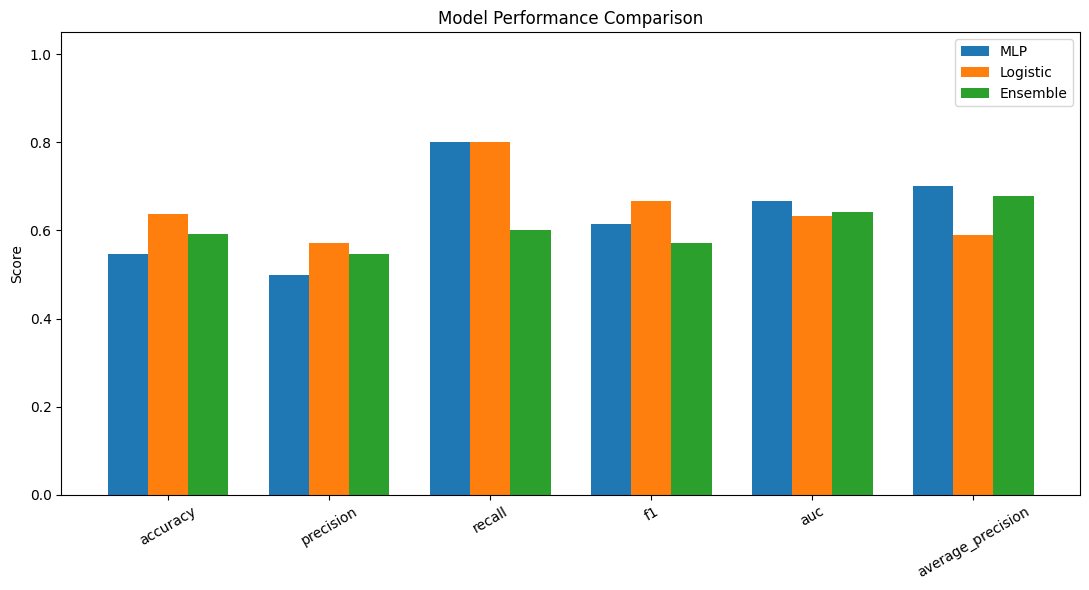

In [17]:
# =========================
# 性能柱状图
# =========================
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc",
    "average_precision"
]

plot_df = model_compare_df.set_index(
    "model"
)[metrics_to_plot]

plt.figure(figsize=(11,6))

x = np.arange(len(metrics_to_plot))

width = 0.25

plt.bar(
    x - width,
    plot_df.loc["MLP"],
    width,
    label="MLP"
)

plt.bar(
    x,
    plot_df.loc["Logistic Regression"],
    width,
    label="Logistic"
)

plt.bar(
    x + width,
    plot_df.loc["MLP + Logistic"],
    width,
    label="Ensemble"
)

plt.xticks(x, metrics_to_plot, rotation=30)

plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.title("Model Performance Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "model_performance_comparison.png"
    ),
    dpi=300
)

plt.show()


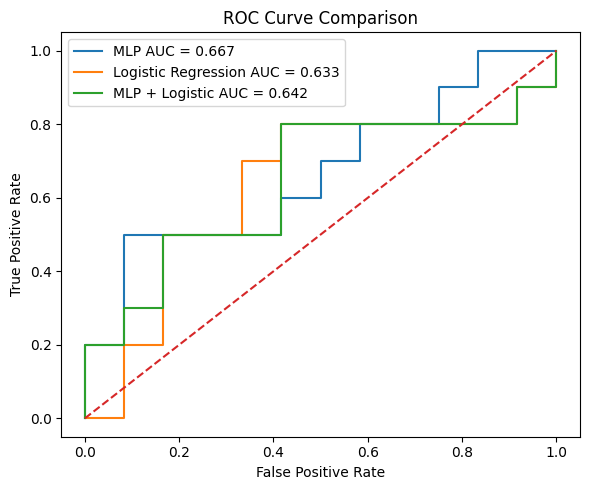

In [18]:
# =========================
# ROC 曲线比较
# =========================
plt.figure(figsize=(6,5))

for name, prob in {

    "MLP": mlp_test_prob,

    "Logistic Regression": logreg_test_prob,

    "MLP + Logistic": ensemble_test_prob

}.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    model_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC = {model_auc:.3f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "roc_curve_model_comparison.png"
    ),
    dpi=300
)

plt.show()


In [1]:
# =========================
# PR 曲线比较
# =========================
plt.figure(figsize=(6,5))

for name, prob in {

    "MLP": mlp_test_prob,

    "Logistic Regression": logreg_test_prob,

    "MLP + Logistic": ensemble_test_prob

}.items():

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        prob
    )

    ap = average_precision_score(
        y_test,
        prob
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{name} AP = {ap:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("PR Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "pr_curve_model_comparison.png"
    ),
    dpi=300
)

plt.show()


NameError: name 'plt' is not defined

In [2]:
# =========================
# 概率分布比较
# =========================
def plot_probability_distribution(
    y_true,
    y_prob,
    threshold,
    title
):

    plt.figure(figsize=(8,5))

    plt.hist(
        y_prob[y_true == 0],
        bins=10,
        alpha=0.7,
        label="Non-recurrence"
    )

    plt.hist(
        y_prob[y_true == 1],
        bins=10,
        alpha=0.7,
        label="Recurrence"
    )

    plt.axvline(
        threshold,
        linestyle="--",
        label=f"Threshold = {threshold:.2f}"
    )

    plt.xlabel("Predicted probability")
    plt.ylabel("Sample count")

    plt.title(title)

    plt.legend()

    plt.tight_layout()

    plt.show()


plot_probability_distribution(
    y_test,
    mlp_test_prob,
    mlp_best_threshold,
    "MLP Probability Distribution"
)

plot_probability_distribution(
    y_test,
    logreg_test_prob,
    logreg_best_threshold,
    "Logistic Regression Probability Distribution"
)

plot_probability_distribution(
    y_test,
    ensemble_test_prob,
    ensemble_best_threshold,
    "Ensemble Probability Distribution"
)


NameError: name 'y_test' is not defined

In [ ]:
# =========================
# PCA embedding
# =========================
embedding_array = mlp_test_embedding.detach().numpy()

pca = PCA(
    n_components=2,
    random_state=RANDOM_SEED
)

embedding_pca = pca.fit_transform(
    embedding_array
)

plt.figure(figsize=(6,5))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1],
    c=y_test,
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("MLP Embedding PCA")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "mlp_embedding_pca.png"
    ),
    dpi=300
)

plt.show()


In [ ]:
# =========================
# 保存结果
# =========================
model_compare_df.to_csv(
    "/Users/chengyuhang/Desktop/model_performance_comparison.csv",
    index=False
)

print("Saved comparison csv.")

print("\nAll figures saved to:")
print(FIG_DIR)

print("\nGenerated figures:")

for file in os.listdir(FIG_DIR):

    if file.endswith(".png"):

        print(file)
